In [1]:
from scipy.io import loadmat
import numpy as np


x =   loadmat("D:\cw Coureses\learning in machin and brain\home work\HW1\LMB_1404_HW1\Q2_data\IN_EAR_EEG.mat")
 
y = loadmat("D:\cw Coureses\learning in machin and brain\home work\HW1\LMB_1404_HW1\Q2_data\labels.mat")
X = x["IN_EAR_EEG"]
Y = y["label"]

print("EEG shape:", X.shape)
print("Labels shape:", Y.shape)


EEG shape: (2, 1250, 140)
Labels shape: (1, 140)


In [2]:
X = np.transpose(X, (2, 0, 1))  # -> (140, 2, 1250)
Y = Y.flatten()                 # -> (140,)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (140, 2, 1250)
Y shape: (140,)


In [3]:
unique, counts = np.unique(Y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")


Label -1: 56 samples
Label 0: 28 samples
Label 1: 56 samples


In [4]:
def mixup_oversample(Xw, Yw, minority_label, target_count, lam=0.4, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    Xw = list(Xw)
    Yw = list(Yw)

    idx_min = np.where(np.array(Yw) == minority_label)[0]
    current = len(idx_min)

    if current == 0:
        print("No samples of the minority class exist")
        return np.array(Xw), np.array(Yw)

    while current < target_count:
        rng = np.random.default_rng(seed=27)
        i, j = rng.choice(idx_min, size=2, replace=True)
        seg1 = Xw[i]
        seg2 = Xw[j]

        # Mixup
        new_seg = lam * seg1 + (1 - lam) * seg2

        Xw.append(new_seg)
        Yw.append(minority_label)
        current += 1

    return np.stack(Xw), np.array(Yw)


In [5]:
classes, counts = np.unique(Y, return_counts=True)
for c, k in zip(classes, counts):
    print(f"Label {c}: {k} windows")

majority_label = classes[np.argmax(counts)]
minority_label = classes[np.argmin(counts)]
max_count = counts.max()

print("Majority:", majority_label, "Minority:", minority_label)


Label -1: 56 windows
Label 0: 28 windows
Label 1: 56 windows
Majority: -1 Minority: 0


In [6]:

X_bal, Y_bal = mixup_oversample(
    X,
    Y,
    minority_label=minority_label,
    target_count=56,
    lam=0.4
)

print("Balanced shape:", X_bal.shape, Y_bal.shape)

classes_b, counts_b = np.unique(Y_bal, return_counts=True)
for c, k in zip(classes_b, counts_b):
    print(f"Label {c}: {k} windows")


Balanced shape: (168, 2, 1250) (168,)
Label -1: 56 windows
Label 0: 56 windows
Label 1: 56 windows


In [7]:
from scipy.signal import butter, filtfilt
fs=512;
def bandpass_filter(sig, low, high, fs=512, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 45),
}


In [8]:
import pywt
def extract_wavelet_features(signal, wavelet='db4', level=8):
    
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)
    feats = []

    for c in coeffs:
        c = np.asarray(c)
        # انرژی نرمال‌شده
        energy = np.sum(c ** 2) / len(c)

        # آنتروپی انرژی
        power = c ** 2
        p = power / (np.sum(power) + 1e-12)
        entropy = -np.sum(p * np.log(p + 1e-12))

        feats.extend([energy, entropy])

    return np.array(feats)


In [9]:
from scipy.signal import welch

def extract_features(signal, fs=512):
    N = len(signal)
    x = signal

    # 1) Mean
    mean = np.mean(x)

    # 2) Std
    std = np.std(x)

    # 3) First-order diff mean
    diff1 = np.diff(x)
    mean_diff1 = np.mean(np.abs(diff1))

    # 4) Normalized diff1
    norm_diff1 = np.mean(np.abs(diff1) / (np.abs(x[:-1]) + 1e-8))

    # 5) Second-order diff mean
    diff2 = np.diff(x, n=2)
    mean_diff2 = np.mean(np.abs(diff2))

    # 6) Normalized diff2
    norm_diff2 = np.mean(np.abs(diff2) / (np.abs(x[:-2]) + 1e-8))

    # 7) Power Spectral Density
    f, Pxx = welch(x, fs=fs, nperseg=256)
    psd = np.trapezoid(Pxx, f)

    # 8) Differential Entropy
    de = 0.5 * np.log(2 * np.pi * np.e * std**2 + 1e-8)

    return np.array([mean, std, mean_diff1, norm_diff1, 
                     mean_diff2, norm_diff2, psd, de])


In [10]:
all_features = []   # مثلا (N_samples_bal, 80 + wavelet + CSP)

for sample in X_bal:       # sample.shape = (2, 1250)
    sample_features = []

  
    for ch in range(2):   # 2 channels
        sig = sample[ch]

        for name, (lo, hi) in bands.items():
            filtered = bandpass_filter(sig, lo, hi, fs=fs)

            feats = extract_features(filtered)   # → 8 features
            sample_features.extend(feats)

    
    for ch in range(2):
        sig = sample[ch]
        w_feats = extract_wavelet_features(sig, wavelet='db4', level=4)
        sample_features.extend(w_feats)

    all_features.append(sample_features)

all_features = np.array(all_features)
print("Feature matrix (without CSP) shape:", all_features.shape)


Feature matrix (without CSP) shape: (168, 100)


In [11]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import f_classif, mutual_info_classif

class CombinedFisherMI(BaseEstimator, TransformerMixin):
    def __init__(self, k=45, alpha=0.5, mode="linear", random_state=None):
        
        self.k = k
        self.alpha = alpha
        self.mode = mode
        self.random_state = random_state

    def _minmax_norm(self, x):
        x = np.nan_to_num(x)
        xmin = np.min(x)
        xmax = np.max(x)
        if xmax - xmin < 1e-12:
            return np.zeros_like(x)
        return (x - xmin) / (xmax - xmin)

    def fit(self, X, y):
        
        fisher_scores, _ = f_classif(X, y)
        mi_scores = mutual_info_classif(X, y, random_state=self.random_state)

        
        F = self._minmax_norm(fisher_scores)
        M = self._minmax_norm(mi_scores)

        
        if self.mode == "linear":
            self.scores_ = self.alpha * F + (1 - self.alpha) * M
        elif self.mode == "product":
            self.scores_ = F * M
        else:
            raise ValueError("mode  'linear'  'product' ")

        
        self.idx_ = np.argsort(self.scores_)[::-1][:self.k]
        return self

    def transform(self, X):
        return X[:, self.idx_]

    def get_support(self, indices=False):
        if indices:
            return self.idx_
        mask = np.zeros_like(self.scores_, dtype=bool)
        mask[self.idx_] = True
        return mask


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import clone
import matplotlib.pyplot as plt
k_values = [ 35, 40, 45, 55,60 ,65]  
feature_selectors = {
    "Fisher": SelectKBest(score_func=f_classif, k=45),
    "MutualInfo": SelectKBest(score_func=mutual_info_classif, k=45),
   # "Combined_F05_lin": CombinedFisherMI(k=45, alpha=0.5, mode="linear", random_state=19),
}

model_builders = {
    "SVM": SVC,
    "LDA": LinearDiscriminantAnalysis,
    "DecisionTree": DecisionTreeClassifier,
    "LogReg": LogisticRegression,
}
X_feat = all_features  
y = Y_bal   

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)
f1_macro = make_scorer(f1_score, average="macro")

results = []

for feat_name, selector in feature_selectors.items():
    print(f"\n{'#'*70}")
    print(f"Feature selection method: {feat_name}")
    print('#'*70)

    for model_name, clf_class in model_builders.items():
        print(f"\nModel: {model_name}")

        sel = clone(selector)

        pipe = Pipeline([
            ("select", sel),
            ("scaler", StandardScaler()),
            ("clf", clf_class()),
        ])

         
        if model_name == "SVM":
            param_grid = {
                "select__k": k_values,            
                "clf__kernel": ["rbf", "linear"],
                "clf__C": [0.1, 1, 10],
                "clf__gamma": ["scale", 0.01, 0.001],
            }
        elif model_name == "LDA":
            param_grid = [
                {
                    "select__k": k_values,
                    "clf__solver": ["svd"],
                    "clf__shrinkage": [None],
                },
                {
                    "select__k": k_values,
                    "clf__solver": ["lsqr"],
                    "clf__shrinkage": ["auto", 0.1, 0.3, 0.5],
                },
            ]
        elif model_name == "DecisionTree":
            param_grid = {
                "select__k": k_values,
                "clf__max_depth": [None, 3, 5, 7],
                "clf__min_samples_split": [2, 5, 10],
                "clf__min_samples_leaf": [1, 2, 4],
            }
        elif model_name == "LogReg":
            param_grid = {
                "select__k": k_values,
                "clf__C": [0.01, 0.1, 1, 10],
                "clf__penalty": ["l2"],
                "clf__solver": ["lbfgs", "liblinear"],
                "clf__max_iter": [1000],
            }

        f1_scores_test = []

        for train_idx, test_idx in cv.split(X_feat, y):
            X_train, X_test = X_feat[train_idx], X_feat[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)

            grid = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                cv=cv2,
                scoring=f1_macro,
                n_jobs=-1
            )
            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_
            y_pred = best_model.predict(X_test)
            test_f1 = f1_score(y_test, y_pred, average="macro")
            f1_scores_test.append(test_f1)

        mean_f1 = np.mean(f1_scores_test)
        std_f1 = np.std(f1_scores_test)

        print(f"  Mean Test F1 (5-fold): {mean_f1:.4f}")
        print(f"  Standard Deviation: {std_f1:.4f}")
        print(f"  Best params (example fold): {grid.best_params_}")

        results.append({
            "feature_method": feat_name,
            "model": model_name,
            "mean_f1": mean_f1,
            "std_f1": std_f1,
            "best_params": grid.best_params_,
        })

df_final = pd.DataFrame(results)
df_final



######################################################################
Feature selection method: Fisher
######################################################################

Model: SVM
  Mean Test F1 (5-fold): 0.7912
  Standard Deviation: 0.0718
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 65}

Model: LDA
  Mean Test F1 (5-fold): 0.6804
  Standard Deviation: 0.0476
  Best params (example fold): {'clf__shrinkage': 'auto', 'clf__solver': 'lsqr', 'select__k': 65}

Model: DecisionTree
  Mean Test F1 (5-fold): 0.5206
  Standard Deviation: 0.0848
  Best params (example fold): {'clf__max_depth': 7, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'select__k': 45}

Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use ano

  Mean Test F1 (5-fold): 0.6204
  Standard Deviation: 0.1075
  Best params (example fold): {'clf__C': 1, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'select__k': 60}

######################################################################
Feature selection method: MutualInfo
######################################################################

Model: SVM
  Mean Test F1 (5-fold): 0.6969
  Standard Deviation: 0.0661
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 45}

Model: LDA
  Mean Test F1 (5-fold): 0.5919
  Standard Deviation: 0.0593
  Best params (example fold): {'clf__shrinkage': 0.3, 'clf__solver': 'lsqr', 'select__k': 40}

Model: DecisionTree
  Mean Test F1 (5-fold): 0.5921
  Standard Deviation: 0.0305
  Best params (example fold): {'clf__max_depth': 7, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'select__k': 35}

Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use ano

  Mean Test F1 (5-fold): 0.6564
  Standard Deviation: 0.0313
  Best params (example fold): {'clf__C': 1, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'select__k': 40}


,feature_method,model,mean_f1,std_f1,best_params
0,Fisher,SVM,0.791155,0.071768,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke..."
1,Fisher,LDA,0.680433,0.047580,"{'clf__shrinkage': 'auto', 'clf__solver': 'lsq..."
2,Fisher,DecisionTree,0.520600,0.084843,"{'clf__max_depth': 7, 'clf__min_samples_leaf':..."
3,Fisher,LogReg,0.620362,0.107526,"{'clf__C': 1, 'clf__max_iter': 1000, 'clf__pen..."
4,MutualInfo,SVM,0.696949,0.066139,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke..."
5,MutualInfo,LDA,0.591859,0.059334,"{'clf__shrinkage': 0.3, 'clf__solver': 'lsqr',..."
6,MutualInfo,DecisionTree,0.592054,0.030538,"{'clf__max_depth': 7, 'clf__min_samples_leaf':..."
7,MutualInfo,LogReg,0.656408,0.031259,"{'clf__C': 1, 'clf__max_iter': 1000, 'clf__pen..."



######################################################################
Feature selection method: Fisher
######################################################################

Model: SVM
  Mean Test F1: 0.7912  ± 0.0718
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 65}

Model: LDA
  Mean Test F1: 0.6804  ± 0.0476
  Best params (example fold): {'clf__shrinkage': 'auto', 'clf__solver': 'lsqr', 'select__k': 65}

Model: DecisionTree
  Mean Test F1: 0.5594  ± 0.0721
  Best params (example fold): {'clf__max_depth': 7, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'select__k': 40}

Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use ano

  Mean Test F1: 0.6204  ± 0.1075
  Best params (example fold): {'clf__C': 1, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'select__k': 60}

######################################################################
Feature selection method: MutualInfo
######################################################################

Model: SVM
  Mean Test F1: 0.6969  ± 0.0661
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 45}

Model: LDA
  Mean Test F1: 0.5919  ± 0.0593
  Best params (example fold): {'clf__shrinkage': 0.3, 'clf__solver': 'lsqr', 'select__k': 40}

Model: DecisionTree
  Mean Test F1: 0.6138  ± 0.1030
  Best params (example fold): {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'select__k': 60}

Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use ano

  Mean Test F1: 0.6564  ± 0.0313
  Best params (example fold): {'clf__C': 1, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'select__k': 40}
  feature_method         model   mean_f1    std_f1
0         Fisher           SVM  0.791155  0.071768
1         Fisher           LDA  0.680433  0.047580
2         Fisher  DecisionTree  0.559409  0.072129
3         Fisher        LogReg  0.620362  0.107526
4     MutualInfo           SVM  0.696949  0.066139
5     MutualInfo           LDA  0.591859  0.059334
6     MutualInfo  DecisionTree  0.613843  0.102990
7     MutualInfo        LogReg  0.656408  0.031259


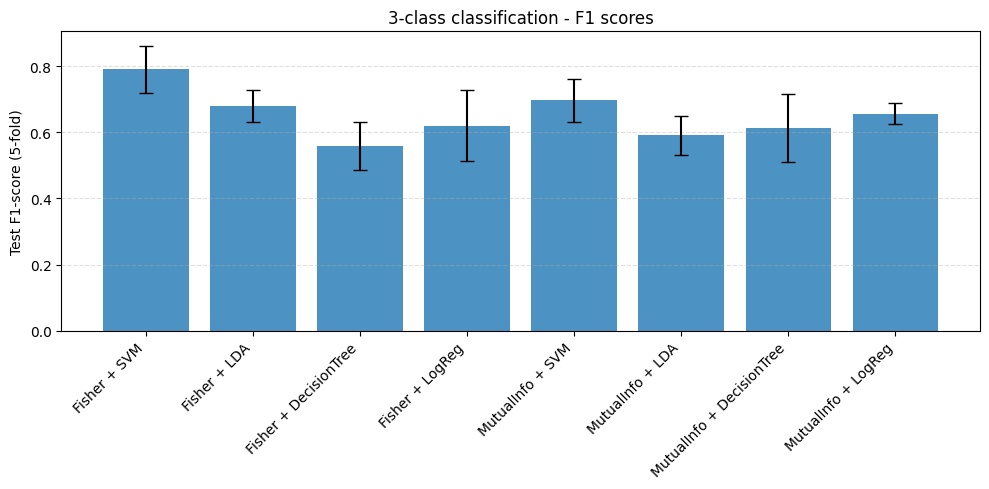

C:\Users\aivic\AppData\Local\Temp\ipykernel_11212\973325827.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


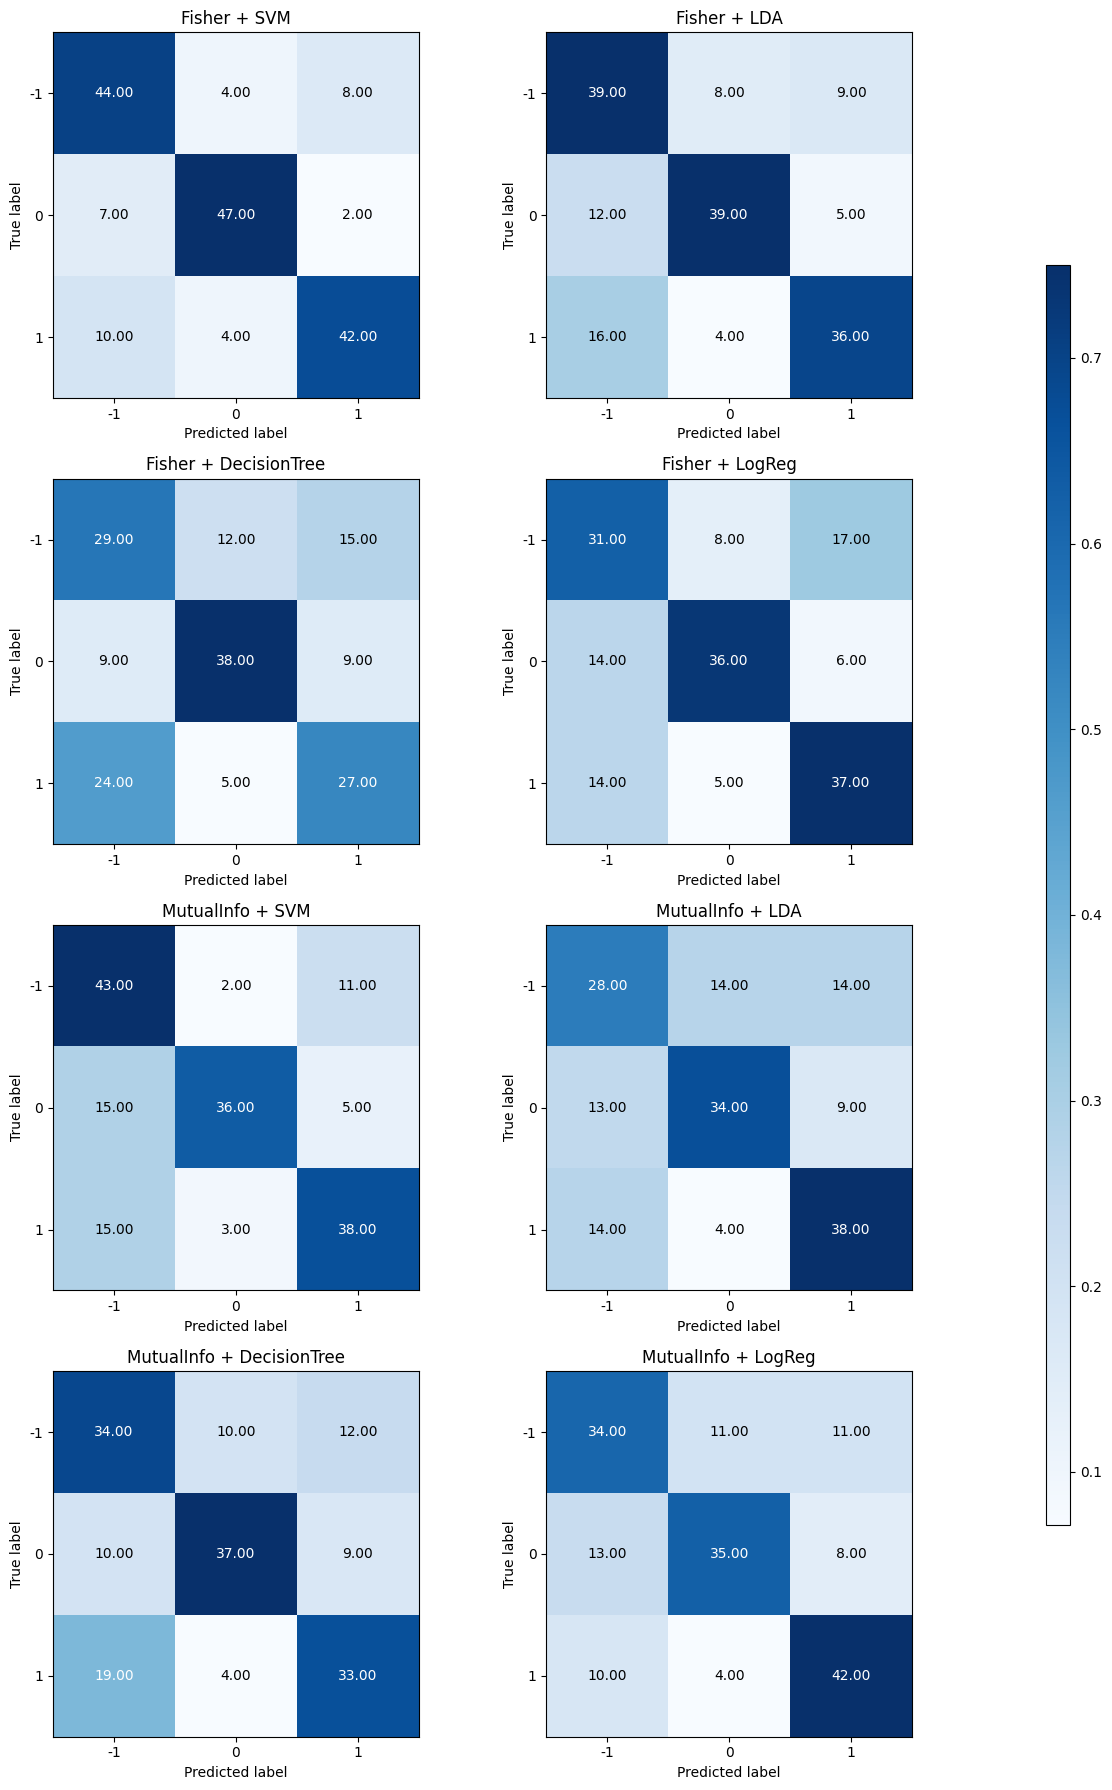

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import clone
import matplotlib.pyplot as plt
k_values = [ 35, 40, 45, 55,60 ,65]   # هرچی خواستی این‌جا بازی کن
feature_selectors = {
    "Fisher": SelectKBest(score_func=f_classif, k=45),
    "MutualInfo": SelectKBest(score_func=mutual_info_classif, k=45),
    #"Combined_F05_lin": CombinedFisherMI(k=45, alpha=0.5, mode="linear", random_state=19),
}

model_builders = {
    "SVM": SVC,
    "LDA": LinearDiscriminantAnalysis,
    "DecisionTree": DecisionTreeClassifier,
    "LogReg": LogisticRegression,
}
X_feat = all_features 
y = Y_bal  

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)
f1_macro = make_scorer(f1_score, average="macro")

results_comb = []

for feat_name, selector in feature_selectors.items():
    print(f"\n{'#'*70}")
    print(f"Feature selection method: {feat_name}")
    print('#'*70)

    for model_name, clf_class in model_builders.items():
        print(f"\nModel: {model_name}")

        sel = clone(selector)

        pipe = Pipeline([
            ("select", sel),
            ("scaler", StandardScaler()),
            ("clf", clf_class()),
        ])

        
        if model_name == "SVM":
            param_grid = {
                "select__k": k_values,          
                "clf__kernel": ["rbf", "linear"],
                "clf__C": [0.1, 1, 10],
                "clf__gamma": ["scale", 0.01, 0.001],
            }
        elif model_name == "LDA":
            param_grid = [
                {
                    "select__k": k_values,
                    "clf__solver": ["svd"],
                    "clf__shrinkage": [None],
                },
                {
                    "select__k": k_values,
                    "clf__solver": ["lsqr"],
                    "clf__shrinkage": ["auto", 0.1, 0.3, 0.5],
                },
            ]
        elif model_name == "DecisionTree":
            param_grid = {
                "select__k": k_values,
                "clf__max_depth": [None, 3, 5, 7],
                "clf__min_samples_split": [2, 5, 10],
                "clf__min_samples_leaf": [1, 2, 4],
            }
        elif model_name == "LogReg":
            param_grid = {
                "select__k": k_values,
                "clf__C": [0.01, 0.1, 1, 10],
                "clf__penalty": ["l2"],
                "clf__solver": ["lbfgs", "liblinear"],
                "clf__max_iter": [1000],
            }

        f1_scores_test = []
        y_pred_list = []
        y_test_list = []
        for train_idx, test_idx in cv.split(X_feat, y):
            X_train, X_test = X_feat[train_idx], X_feat[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)

            grid = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                cv=cv2,
                scoring=f1_macro,
                n_jobs=-1
            )
            
            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_
            y_pred = best_model.predict(X_test)

            y_pred_list.append(y_pred)
            y_test_list.append(y_test)

            test_f1 = f1_score(y_test, y_pred, average="macro")
            f1_scores_test.append(test_f1)

        mean_f1 = np.mean(f1_scores_test)
        std_f1 = np.std(f1_scores_test)

        print(f"  Mean Test F1: {mean_f1:.4f}  ± {std_f1:.4f}")
        print(f"  Best params (example fold): {grid.best_params_}")
        item = {
            "feature_method": feat_name,
            "model": model_name,
            "mean_f1": mean_f1,
            "std_f1": std_f1,
            "best_params": grid.best_params_,
            "y_pred": y_pred_list,
            "y_test": y_test_list,
        }
        results_comb.append(item)


df_comb = pd.DataFrame(results_comb)
print(df_comb[["feature_method", "model", "mean_f1", "std_f1"]])


fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(len(df_comb))
ax.bar(idx, df_comb["mean_f1"], yerr=df_comb["std_f1"], alpha=0.8, capsize=5)
ax.set_xticks(idx)
ax.set_xticklabels(df_comb["feature_method"] + " + " + df_comb["model"], rotation=45, ha="right")
ax.set_ylabel("Test F1-score (5-fold)")
ax.set_title("3-class classification - F1 scores")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

labels = np.unique(y)

rows, cols = 4, 2     
fig, axes = plt.subplots(rows, cols, figsize=(12, 18))

for ax, item in zip(axes.ravel(), results_comb):
    y_pred_all = np.concatenate(item["y_pred"])
    y_test_all = np.concatenate(item["y_test"])

    cm = confusion_matrix(y_test_all, y_pred_all, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    ax.set_title(f"{item['feature_method']} + {item['model']}")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > cm.max() / 2 else "black")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()



######################################################################
Class 0 vs 1
######################################################################

Feature selection: Fisher
Model: SVM
  Mean Test F1: 0.8203  ± 0.0558
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 40}
Model: LDA
  Mean Test F1: 0.7278  ± 0.0611
  Best params (example fold): {'clf__shrinkage': None, 'clf__solver': 'svd'}
Model: DecisionTree
  Mean Test F1: 0.6588  ± 0.0697
  Best params (example fold): {'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'select__k': 60}
Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Mean Test F1: 0.7222  ± 0.0604
  Best params (example fold): {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'select__k': 45}

Feature selection: MutualInfo
Model: SVM
  Mean Test F1: 0.7669  ± 0.0478
  Best params (example fold): {'clf__C': 1, 'clf__gamma': 0.001, 'clf__kernel': 'rbf', 'select__k': 55}
Model: LDA
  Mean Test F1: 0.8306  ± 0.0642
  Best params (example fold): {'select__k': 35}
Model: DecisionTree
  Mean Test F1: 0.7562  ± 0.0552
  Best params (example fold): {'clf__max_depth': 7, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'select__k': 55}
Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Mean Test F1: 0.6839  ± 0.0981
  Best params (example fold): {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'select__k': 40}
  class_combination feature_method         model   mean_f1    std_f1
0      Class 0 vs 1         Fisher           SVM  0.820297  0.055806
1      Class 0 vs 1         Fisher           LDA  0.727773  0.061086
2      Class 0 vs 1         Fisher  DecisionTree  0.658788  0.069721
3      Class 0 vs 1         Fisher        LogReg  0.722152  0.060397
4      Class 0 vs 1     MutualInfo           SVM  0.766864  0.047809
5      Class 0 vs 1     MutualInfo           LDA  0.830581  0.064208
6      Class 0 vs 1     MutualInfo  DecisionTree  0.756171  0.055155
7      Class 0 vs 1     MutualInfo        LogReg  0.683864  0.098089


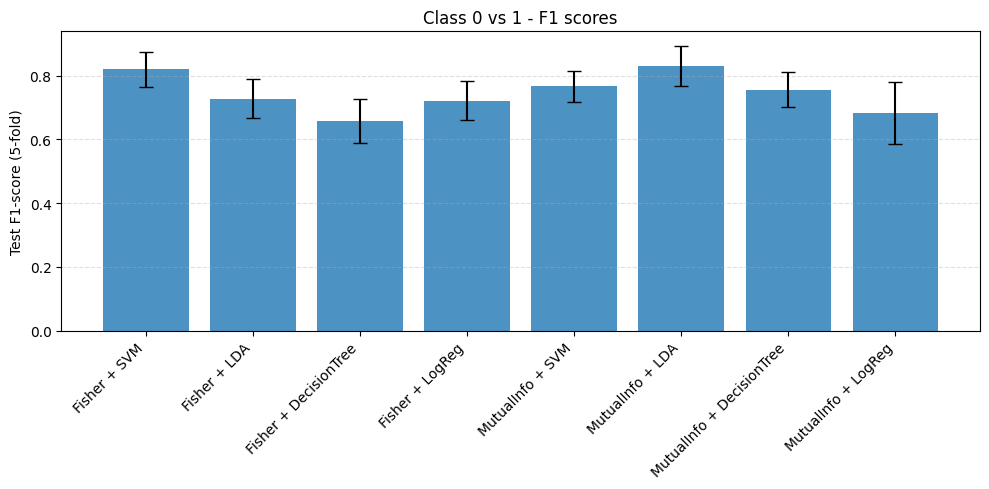

C:\Users\aivic\AppData\Local\Temp\ipykernel_11212\3121479143.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


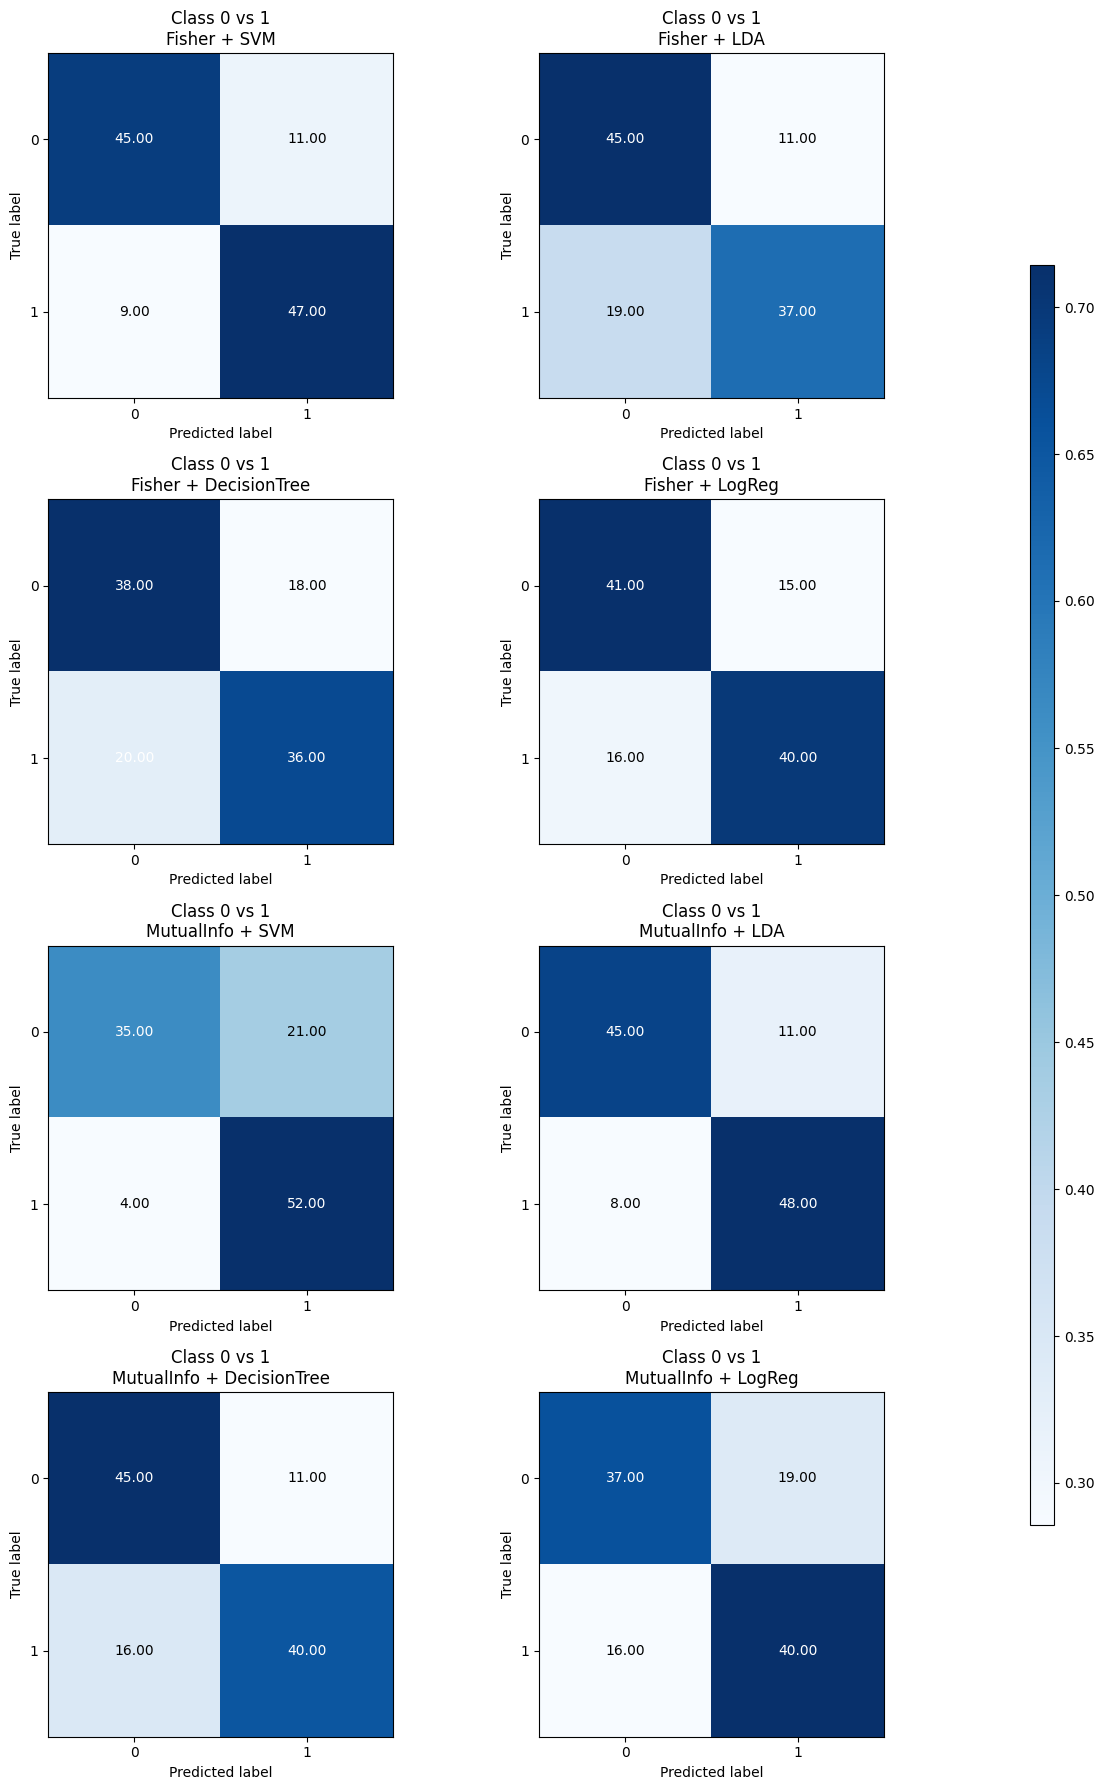


######################################################################
Class 0 vs -1
######################################################################

Feature selection: Fisher
Model: SVM


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan 

  Mean Test F1: 0.7320  ± 0.0677
  Best params (example fold): {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 35}
Model: LDA


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


  Mean Test F1: 0.7924  ± 0.0641
  Best params (example fold): {'select__k': 35}
Model: DecisionTree


...

c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan 

  Mean Test F1: 0.6997  ± 0.0800
  Best params (example fold): {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'select__k': 35}
Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan

  Mean Test F1: 0.7183  ± 0.0636
  Best params (example fold): {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'select__k': 35}
  class_combination feature_method         model   mean_f1    std_f1
0     Class 0 vs -1         Fisher           SVM  0.732036  0.067709
1     Class 0 vs -1         Fisher           LDA  0.792418  0.064076
2     Class 0 vs -1         Fisher  DecisionTree  0.649857  0.078159
3     Class 0 vs -1         Fisher        LogReg  0.709250  0.087296
4     Class 0 vs -1     MutualInfo           SVM  0.732036  0.067709
5     Class 0 vs -1     MutualInfo           LDA  0.785855  0.099297
6     Class 0 vs -1     MutualInfo  DecisionTree  0.699670  0.080010
7     Class 0 vs -1     MutualInfo        LogReg  0.718288  0.063644


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(


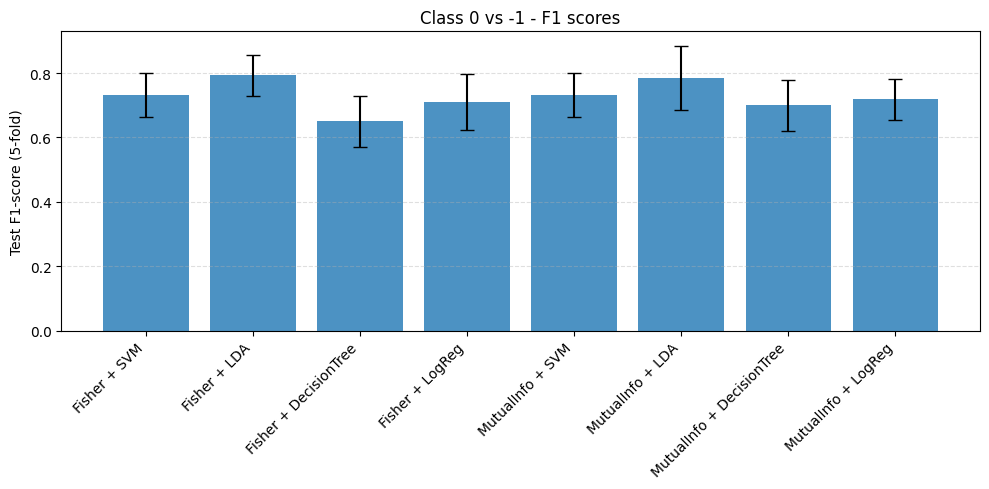

C:\Users\aivic\AppData\Local\Temp\ipykernel_11212\3121479143.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


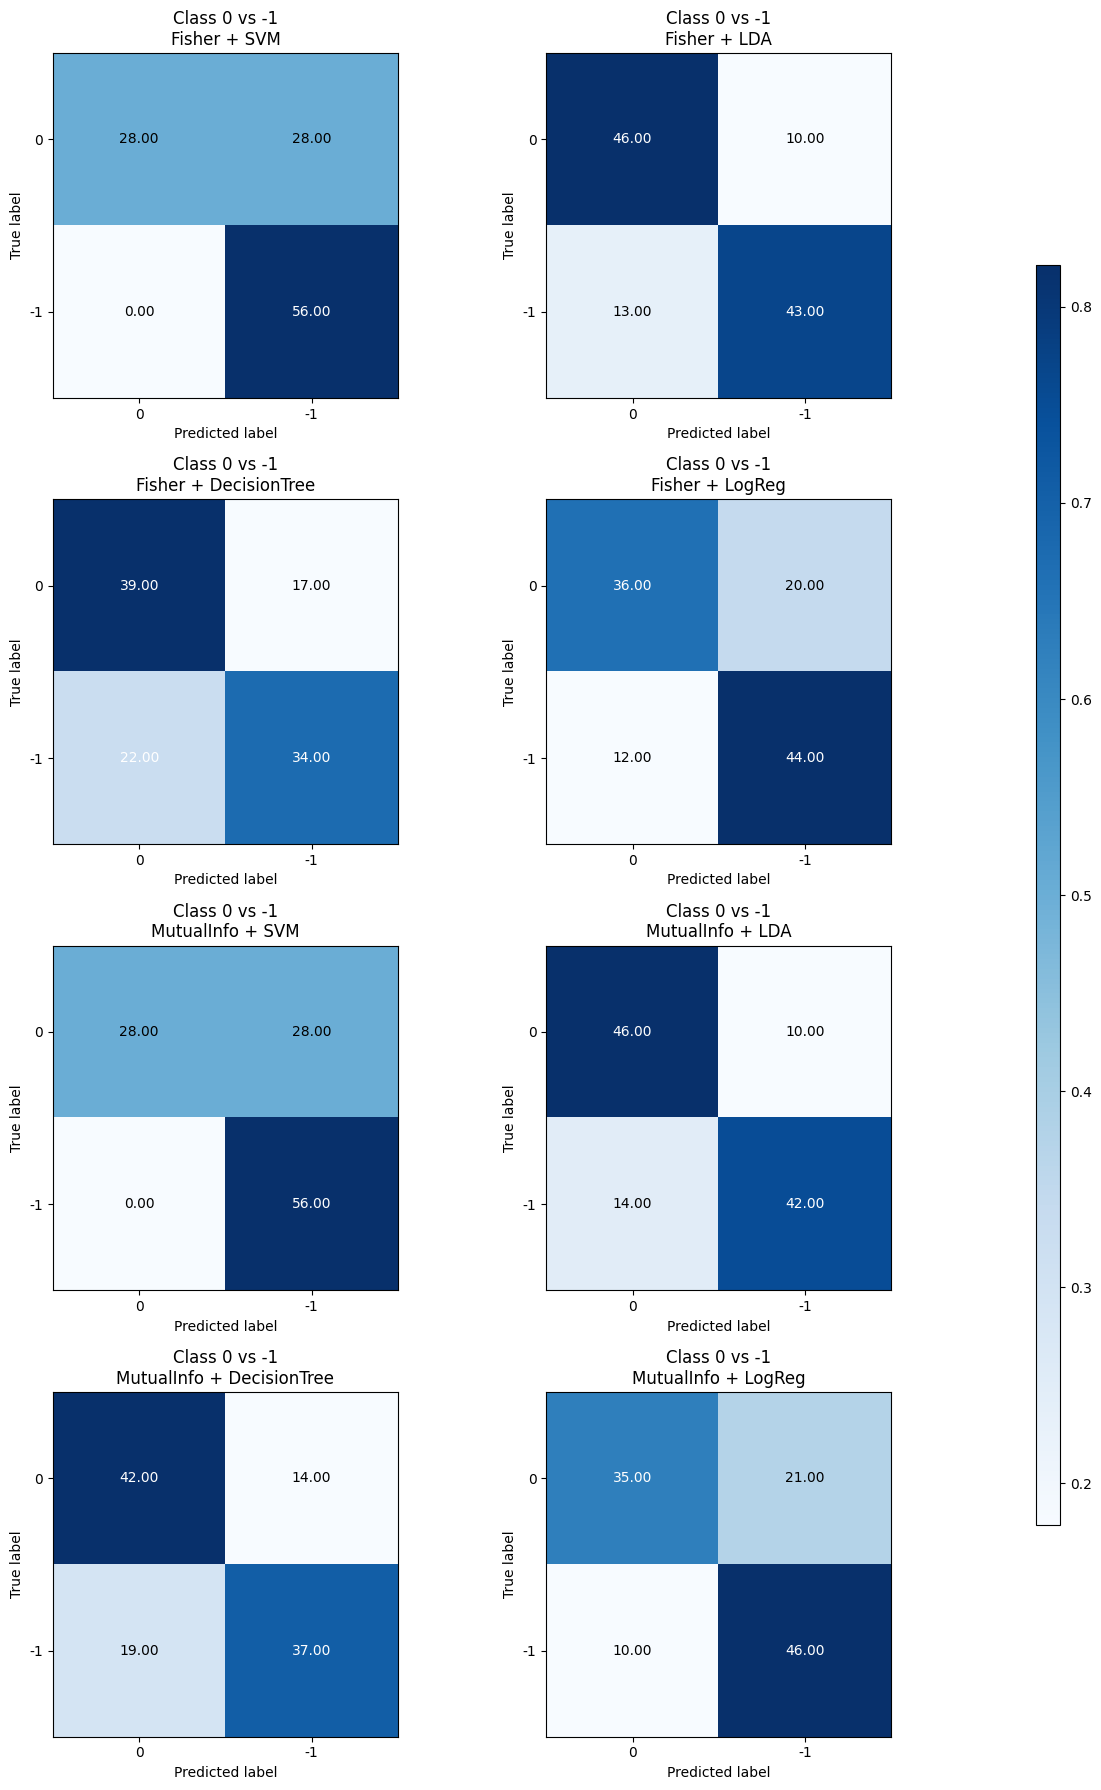


######################################################################
Class 1 vs -1
######################################################################

Feature selection: Fisher
Model: SVM
  Mean Test F1: 0.7203  ± 0.0779
  Best params (example fold): {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear', 'select__k': 65}
Model: LDA
  Mean Test F1: 0.6343  ± 0.0707
  Best params (example fold): {'select__k': 60}
Model: DecisionTree
  Mean Test F1: 0.5518  ± 0.0955
  Best params (example fold): {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'select__k': 35}
Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Mean Test F1: 0.7195  ± 0.0954
  Best params (example fold): {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'select__k': 65}

Feature selection: MutualInfo
Model: SVM
  Mean Test F1: 0.6829  ± 0.0795
  Best params (example fold): {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear', 'select__k': 35}
Model: LDA
  Mean Test F1: 0.6194  ± 0.0601
  Best params (example fold): {'clf__shrinkage': 'auto', 'clf__solver': 'lsqr'}
Model: DecisionTree
  Mean Test F1: 0.6817  ± 0.0400
  Best params (example fold): {'clf__max_depth': None, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'select__k': 35}
Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Mean Test F1: 0.7198  ± 0.0933
  Best params (example fold): {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'select__k': 60}
  class_combination feature_method         model   mean_f1    std_f1
0     Class 1 vs -1         Fisher           SVM  0.720292  0.077923
1     Class 1 vs -1         Fisher           LDA  0.634317  0.070715
2     Class 1 vs -1         Fisher  DecisionTree  0.551760  0.095461
3     Class 1 vs -1         Fisher        LogReg  0.719477  0.095402
4     Class 1 vs -1     MutualInfo           SVM  0.682853  0.079514
5     Class 1 vs -1     MutualInfo           LDA  0.619427  0.060083
6     Class 1 vs -1     MutualInfo  DecisionTree  0.681737  0.039961
7     Class 1 vs -1     MutualInfo        LogReg  0.719832  0.093350


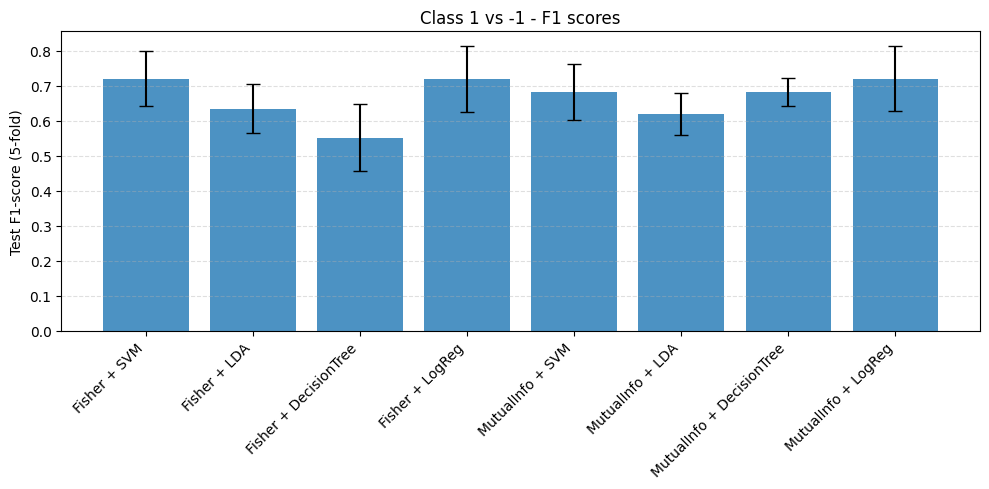

C:\Users\aivic\AppData\Local\Temp\ipykernel_11212\3121479143.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


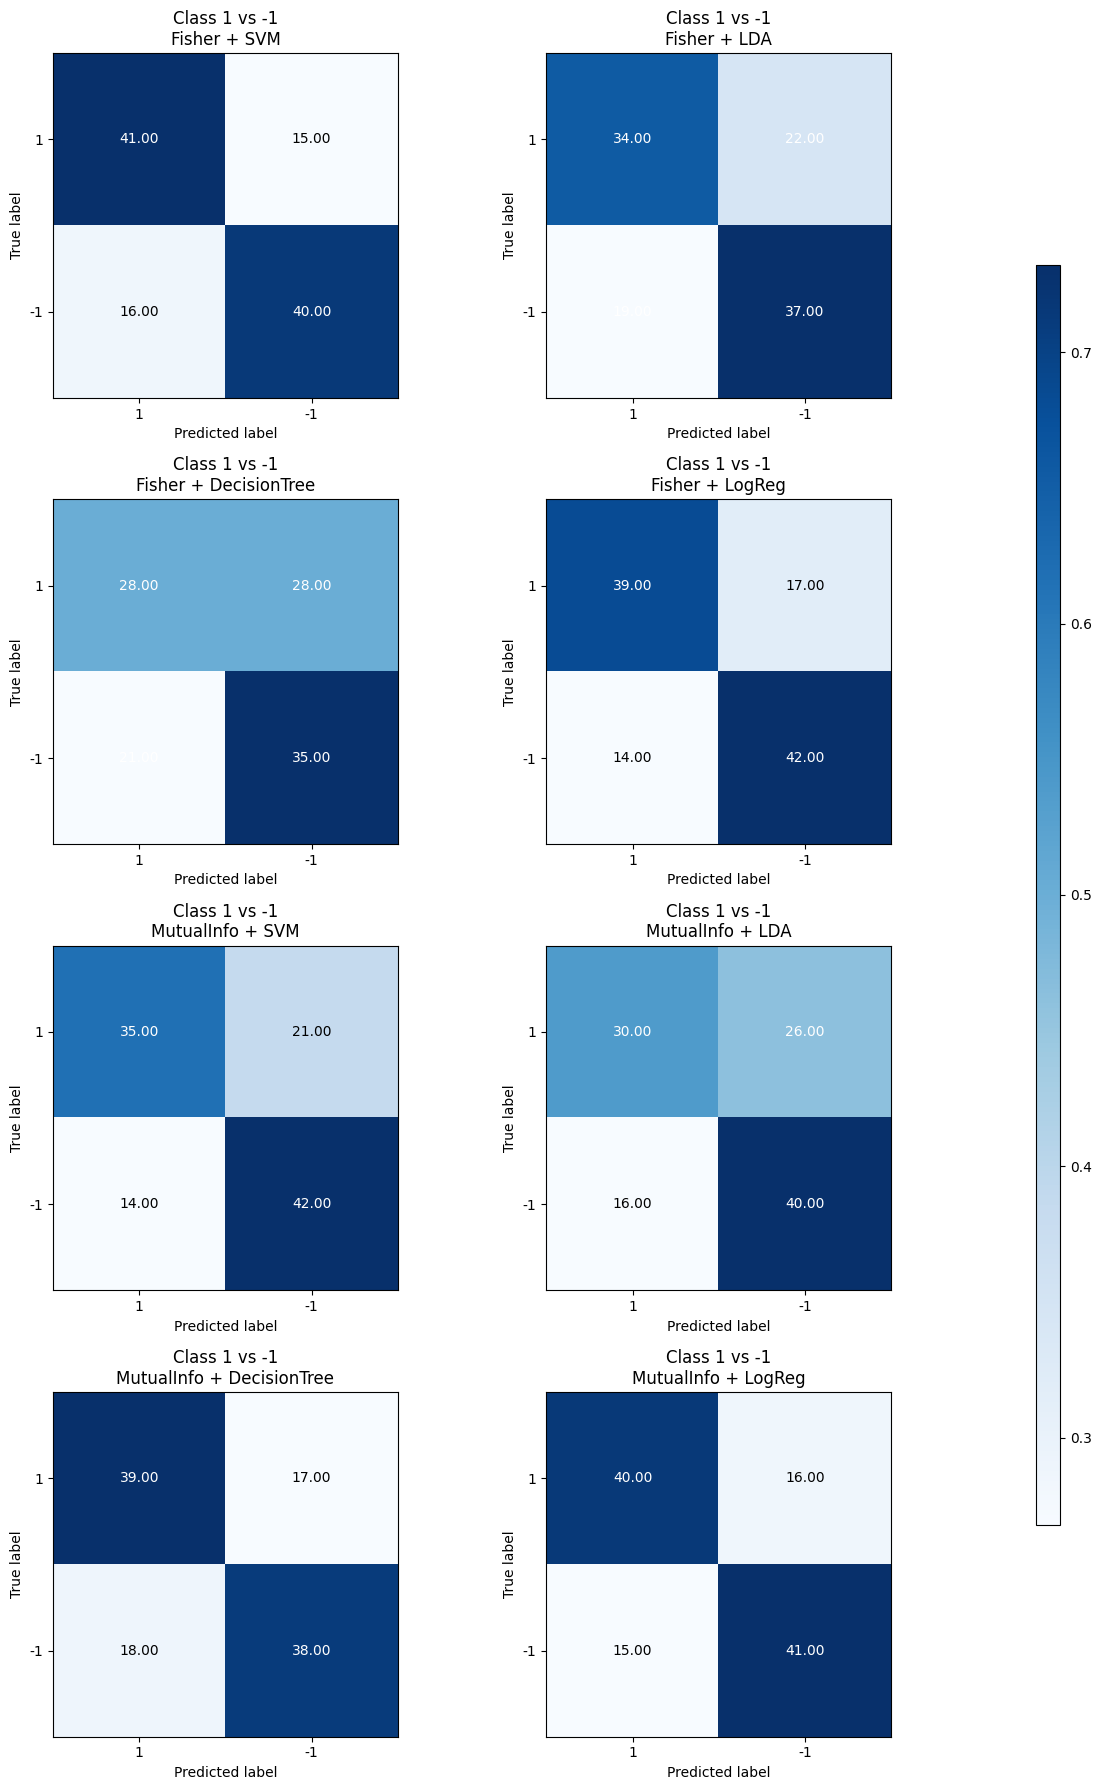

   class_combination feature_method         model   mean_f1    std_f1
0       Class 0 vs 1         Fisher           SVM  0.820297  0.055806
1       Class 0 vs 1         Fisher           LDA  0.727773  0.061086
2       Class 0 vs 1         Fisher  DecisionTree  0.658788  0.069721
3       Class 0 vs 1         Fisher        LogReg  0.722152  0.060397
4       Class 0 vs 1     MutualInfo           SVM  0.766864  0.047809
5       Class 0 vs 1     MutualInfo           LDA  0.830581  0.064208
6       Class 0 vs 1     MutualInfo  DecisionTree  0.756171  0.055155
7       Class 0 vs 1     MutualInfo        LogReg  0.683864  0.098089
8      Class 0 vs -1         Fisher           SVM  0.732036  0.067709
9      Class 0 vs -1         Fisher           LDA  0.792418  0.064076
10     Class 0 vs -1         Fisher  DecisionTree  0.649857  0.078159
11     Class 0 vs -1         Fisher        LogReg  0.709250  0.087296
12     Class 0 vs -1     MutualInfo           SVM  0.732036  0.067709
13     Class 0 vs -1

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import clone
import matplotlib.pyplot as plt
k_values = [ 35, 40, 45, 55,60 ,65]
feature_selectors = {
    "Fisher": SelectKBest(score_func=f_classif, k=23),
    "MutualInfo": SelectKBest(score_func=mutual_info_classif, k=23),
}

model_builders = {
    "SVM": SVC,
    "LDA": LinearDiscriminantAnalysis,
    "DecisionTree": DecisionTreeClassifier,
    "LogReg": LogisticRegression,
}

X_feat = all_features
y = Y_bal

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=19)
f1_macro = make_scorer(f1_score, average="macro")

class_combinations = [
    ("Class 0 vs 1", [0, 1]),
    ("Class 0 vs -1", [0, -1]),
    ("Class 1 vs -1", [1, -1])
]

results_all = []

for comb_name, class_vals in class_combinations:
    print("\n" + "#" * 70)
    print(f"{comb_name}")
    print("#" * 70)

    mask = np.isin(y, class_vals)
    X_comb = X_feat[mask]
    y_comb = y[mask]

    results_comb = []

    for feat_name, selector in feature_selectors.items():
        print(f"\nFeature selection: {feat_name}")

        for model_name, clf_class in model_builders.items():
            print(f"Model: {model_name}")

            if model_name == "SVM":
                param_grid = {
                    "select__k": k_values,
                    "clf__kernel": ["rbf", "linear"],
                    "clf__C": [0.1, 1, 10],
                    "clf__gamma": ["scale", 0.01, 0.001],
                }
            elif model_name == "LDA":
                param_grid = [
                    {"select__k": k_values},
                    {"clf__solver": ["svd"], "clf__shrinkage": [None]},
                    {"clf__solver": ["lsqr"], "clf__shrinkage": ["auto", 0.1, 0.3, 0.5]},
                ]
            elif model_name == "DecisionTree":
                param_grid = {
                     "select__k": k_values,
                    "clf__max_depth": [None, 3, 5, 7],
                    "clf__min_samples_split": [2, 5, 10],
                    "clf__min_samples_leaf": [1, 2, 4],
                }
            elif model_name == "LogReg":
                param_grid = {
                     "select__k": k_values,
                    "clf__C": [0.01, 0.1, 1, 10],
                    "clf__penalty": ["l2"],
                    "clf__solver": ["saga"],
                }

            f1_scores_test = []
            y_pred_list = []
            y_test_list = []

            for train_idx, test_idx in cv_outer.split(X_comb, y_comb):
                X_train, X_test = X_comb[train_idx], X_comb[test_idx]
                y_train, y_test = y_comb[train_idx], y_comb[test_idx]

                sel = clone(selector)
                pipe = Pipeline([
                    ("select", sel),
                    ("scaler", StandardScaler()),
                    ("clf", clf_class()),
                ])

                cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=23)

                grid = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    cv=cv_inner,
                    scoring=f1_macro,
                    n_jobs=-1
                )
                grid.fit(X_train, y_train)

                best_model = grid.best_estimator_
                y_pred = best_model.predict(X_test)

                y_pred_list.append(y_pred)
                y_test_list.append(y_test)

                test_f1 = f1_score(y_test, y_pred, average="macro")
                f1_scores_test.append(test_f1)

            mean_f1 = np.mean(f1_scores_test)
            std_f1 = np.std(f1_scores_test)

            print(f"  Mean Test F1: {mean_f1:.4f}  ± {std_f1:.4f}")
            print(f"  Best params (example fold): {grid.best_params_}")
            item = {
                "class_combination": comb_name,
                "feature_method": feat_name,
                "model": model_name,
                "mean_f1": mean_f1,
                "std_f1": std_f1,
                "best_params": grid.best_params_,
                "y_pred": y_pred_list,
                "y_test": y_test_list,
            }
            results_comb.append(item)
            results_all.append(item)

    df_comb = pd.DataFrame(results_comb)
    print(df_comb[["class_combination", "feature_method", "model", "mean_f1", "std_f1"]])

    fig, ax = plt.subplots(figsize=(10, 5))
    idx = np.arange(len(df_comb))
    ax.bar(idx, df_comb["mean_f1"], yerr=df_comb["std_f1"], alpha=0.8, capsize=5)
    ax.set_xticks(idx)
    ax.set_xticklabels(df_comb["feature_method"] + " + " + df_comb["model"], rotation=45, ha="right")
    ax.set_ylabel("Test F1-score (5-fold)")
    ax.set_title(f"{comb_name} - F1 scores")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    n_models = len(results_comb)
    rows, cols = 4, 2
    fig, axes = plt.subplots(rows, cols, figsize=(12, 18))

    for ax, item in zip(axes.ravel(), results_comb):
        y_pred_all = np.concatenate(item["y_pred"])
        y_test_all = np.concatenate(item["y_test"])

        cm = confusion_matrix(y_test_all, y_pred_all, labels=class_vals)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
        ax.set_title(f"{comb_name}\n{item['feature_method']} + {item['model']}")

        ax.set_xticks(np.arange(len(class_vals)))
        ax.set_yticks(np.arange(len(class_vals)))
        ax.set_xticklabels(class_vals)
        ax.set_yticklabels(class_vals)

        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = cm[i, j]
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        color="white" if val > cm.max() / 2 else "black")

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

df_all = pd.DataFrame(results_all)
print(df_all[["class_combination", "feature_method", "model", "mean_f1", "std_f1"]])
